# Домашнее задание #4: исследование линейной регрессии
- Цель задания — провести полный цикл построения модели машинного обучения: взять данные, провести предобработку и разведочный анализ (EDA),
поработать с признаками, обучить модель (или модели) линейной регрессии, сравнить результаты и сделать обоснованные выводы о качестве
полученного решения.
- Задача — написать код и сопроводить его текстовыми комментариями так, чтобы работа читалась как небольшое исследованиенебольшое исследование, а не просто набор ячеек
с кодом. В ходе работы вы должны дать развернутые ответы на ряд ключевых вопросов (см. ниже).

In [357]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score

## 1. Выбор датасета
В качестве датасета был выбран датасет с ценами на Тойоту.

In [358]:
df = pd.read_csv("ToyotaCorolla.csv")

## 2. EDA

In [359]:
display(df.head())
display(df.tail())
display(df.info())
display(df['Fuel_Type'].unique())
display(df['Color'].unique())
display(df.describe())
display(df.isnull().sum())

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0
1435,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,5,1998,1,Petrol,110,0,...,0,1,0,0,0,0,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

None

<StringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

<StringArray>
[  'Blue', 'Silver',  'Black',  'White',   'Grey',    'Red',  'Green',
 'Yellow', 'Violet',  'Beige']
Length: 10, dtype: str

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

## 3. Feature engineering

Т.к. мы собираемся строить линейную регрессию, то посмотрим, какие признаки сильнее всего влияют на цену (наш таргет в данном случае). Сделаем также one-key encoding, построим 2 матрицы корреляций (после энкодинга и до), выделим и построим матрицу корреляций для признаков, у которых корелляция по модулю > 0.5

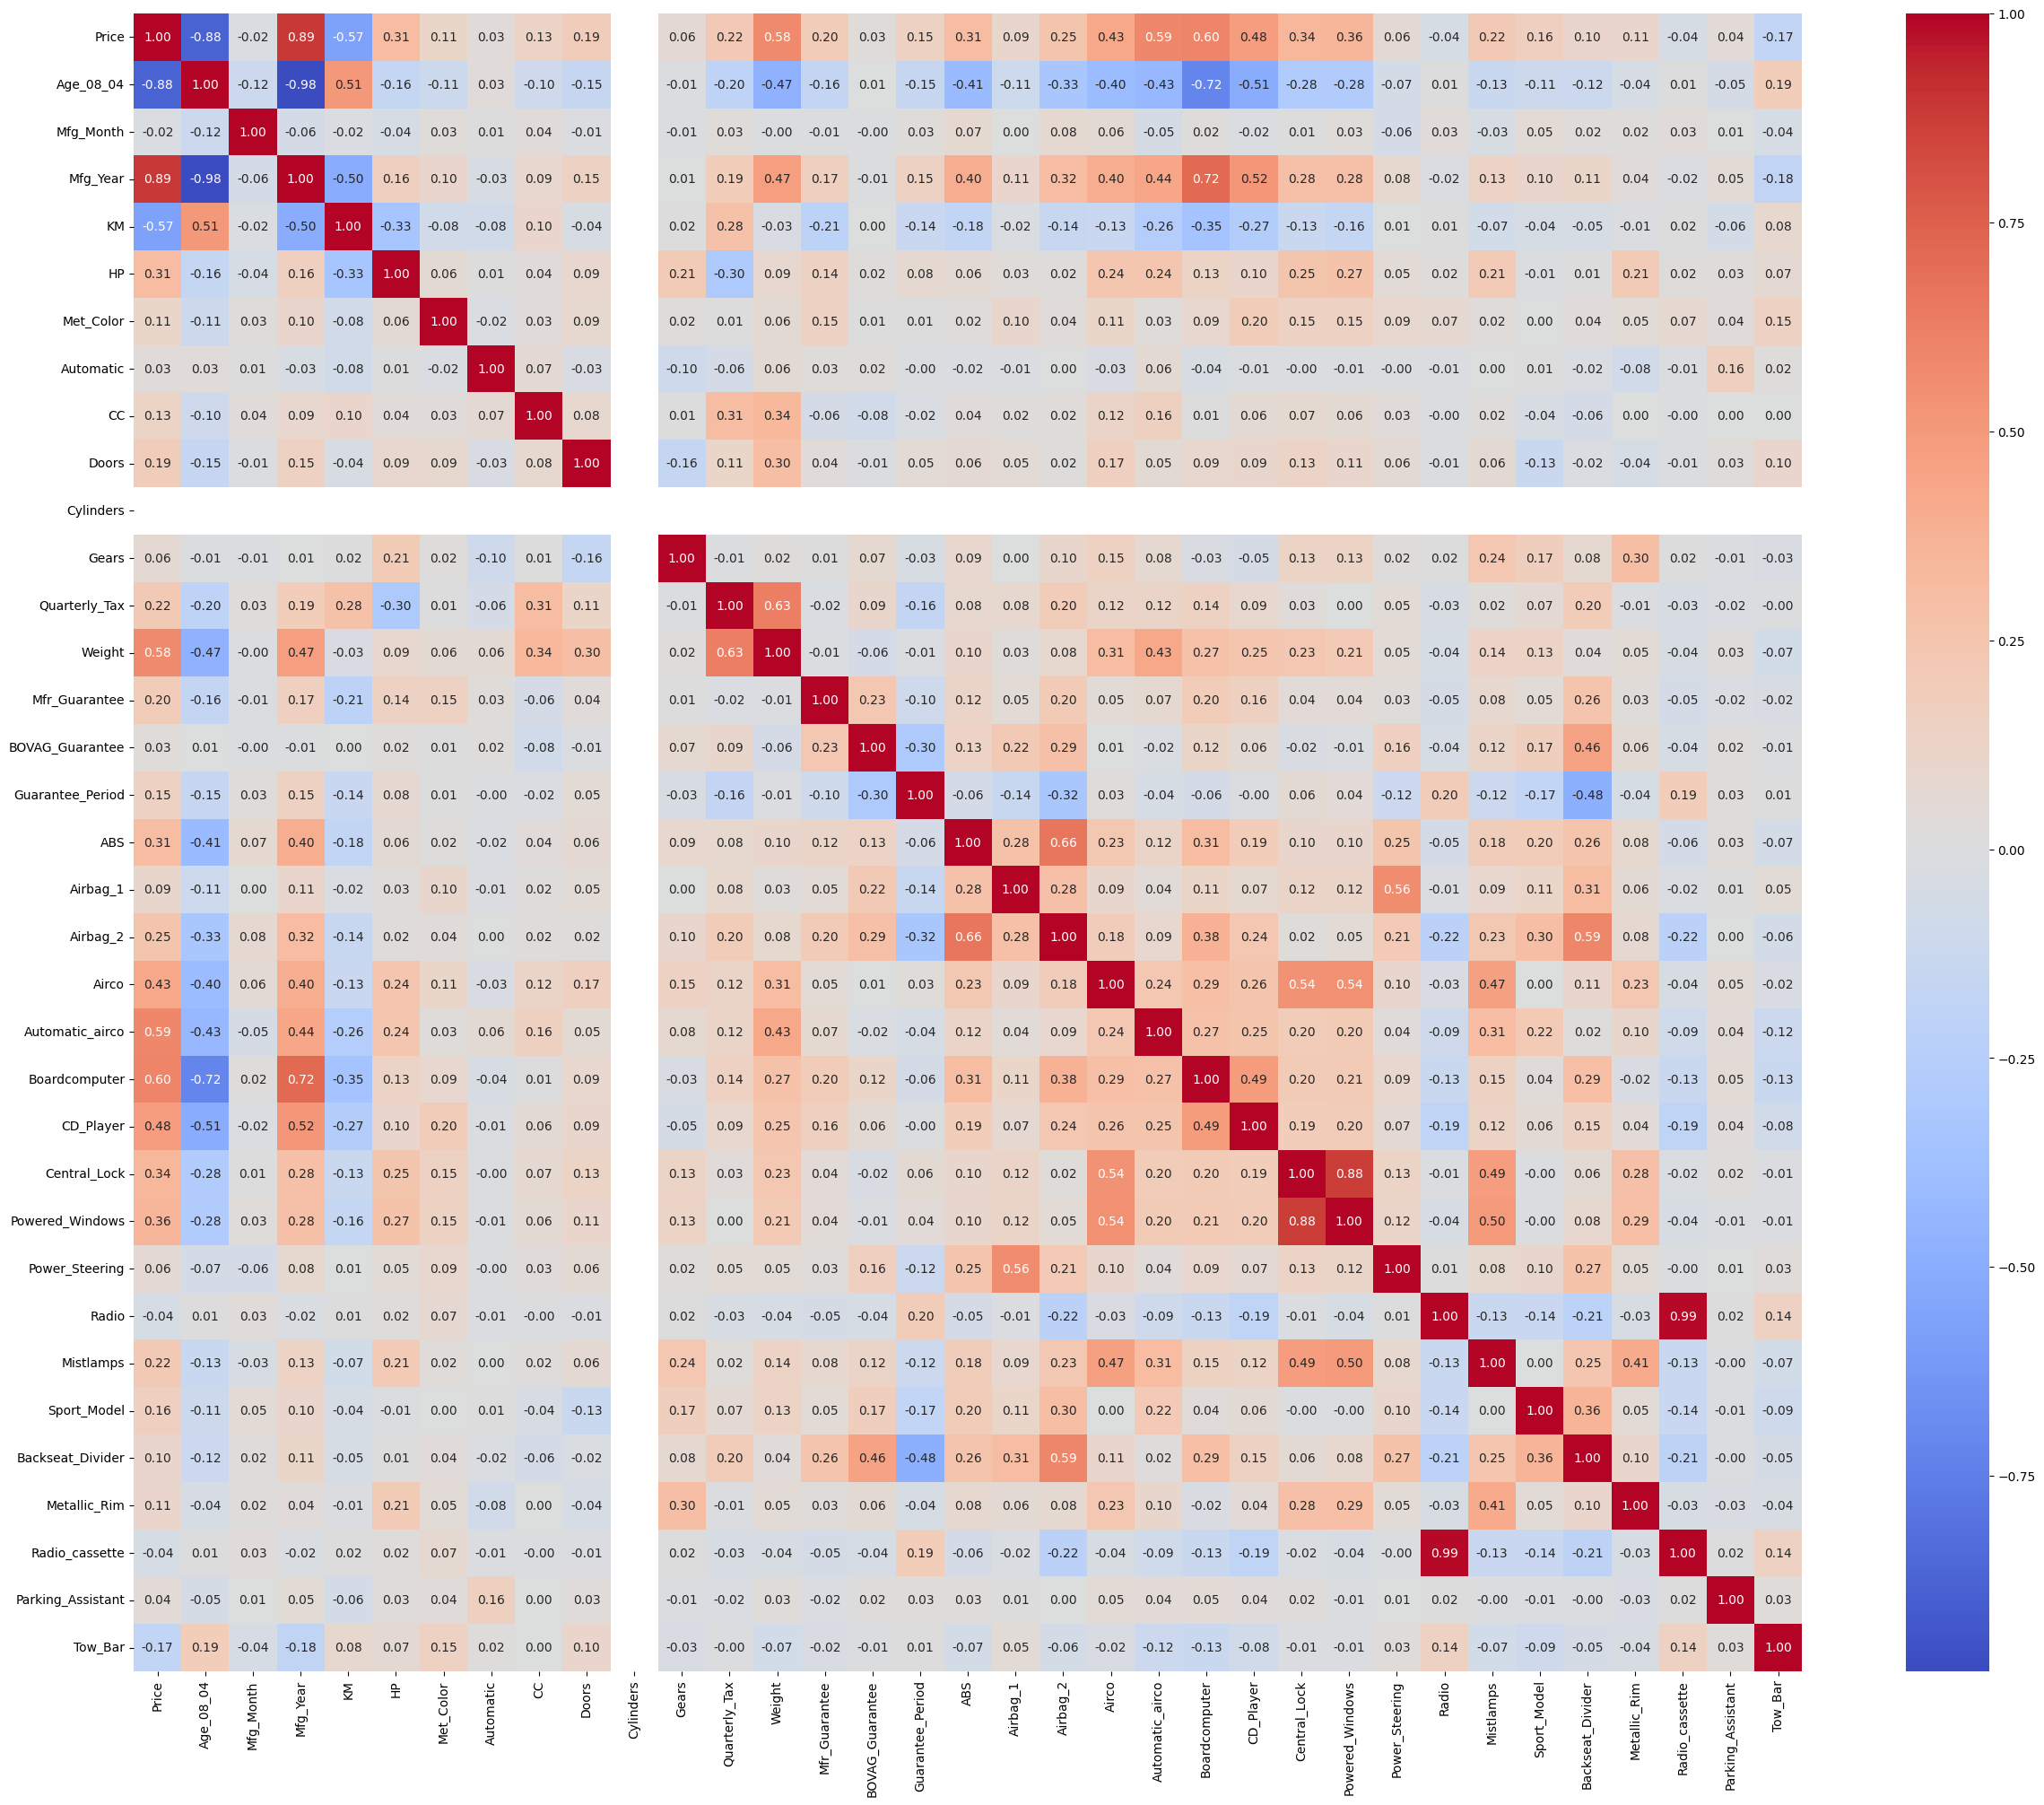

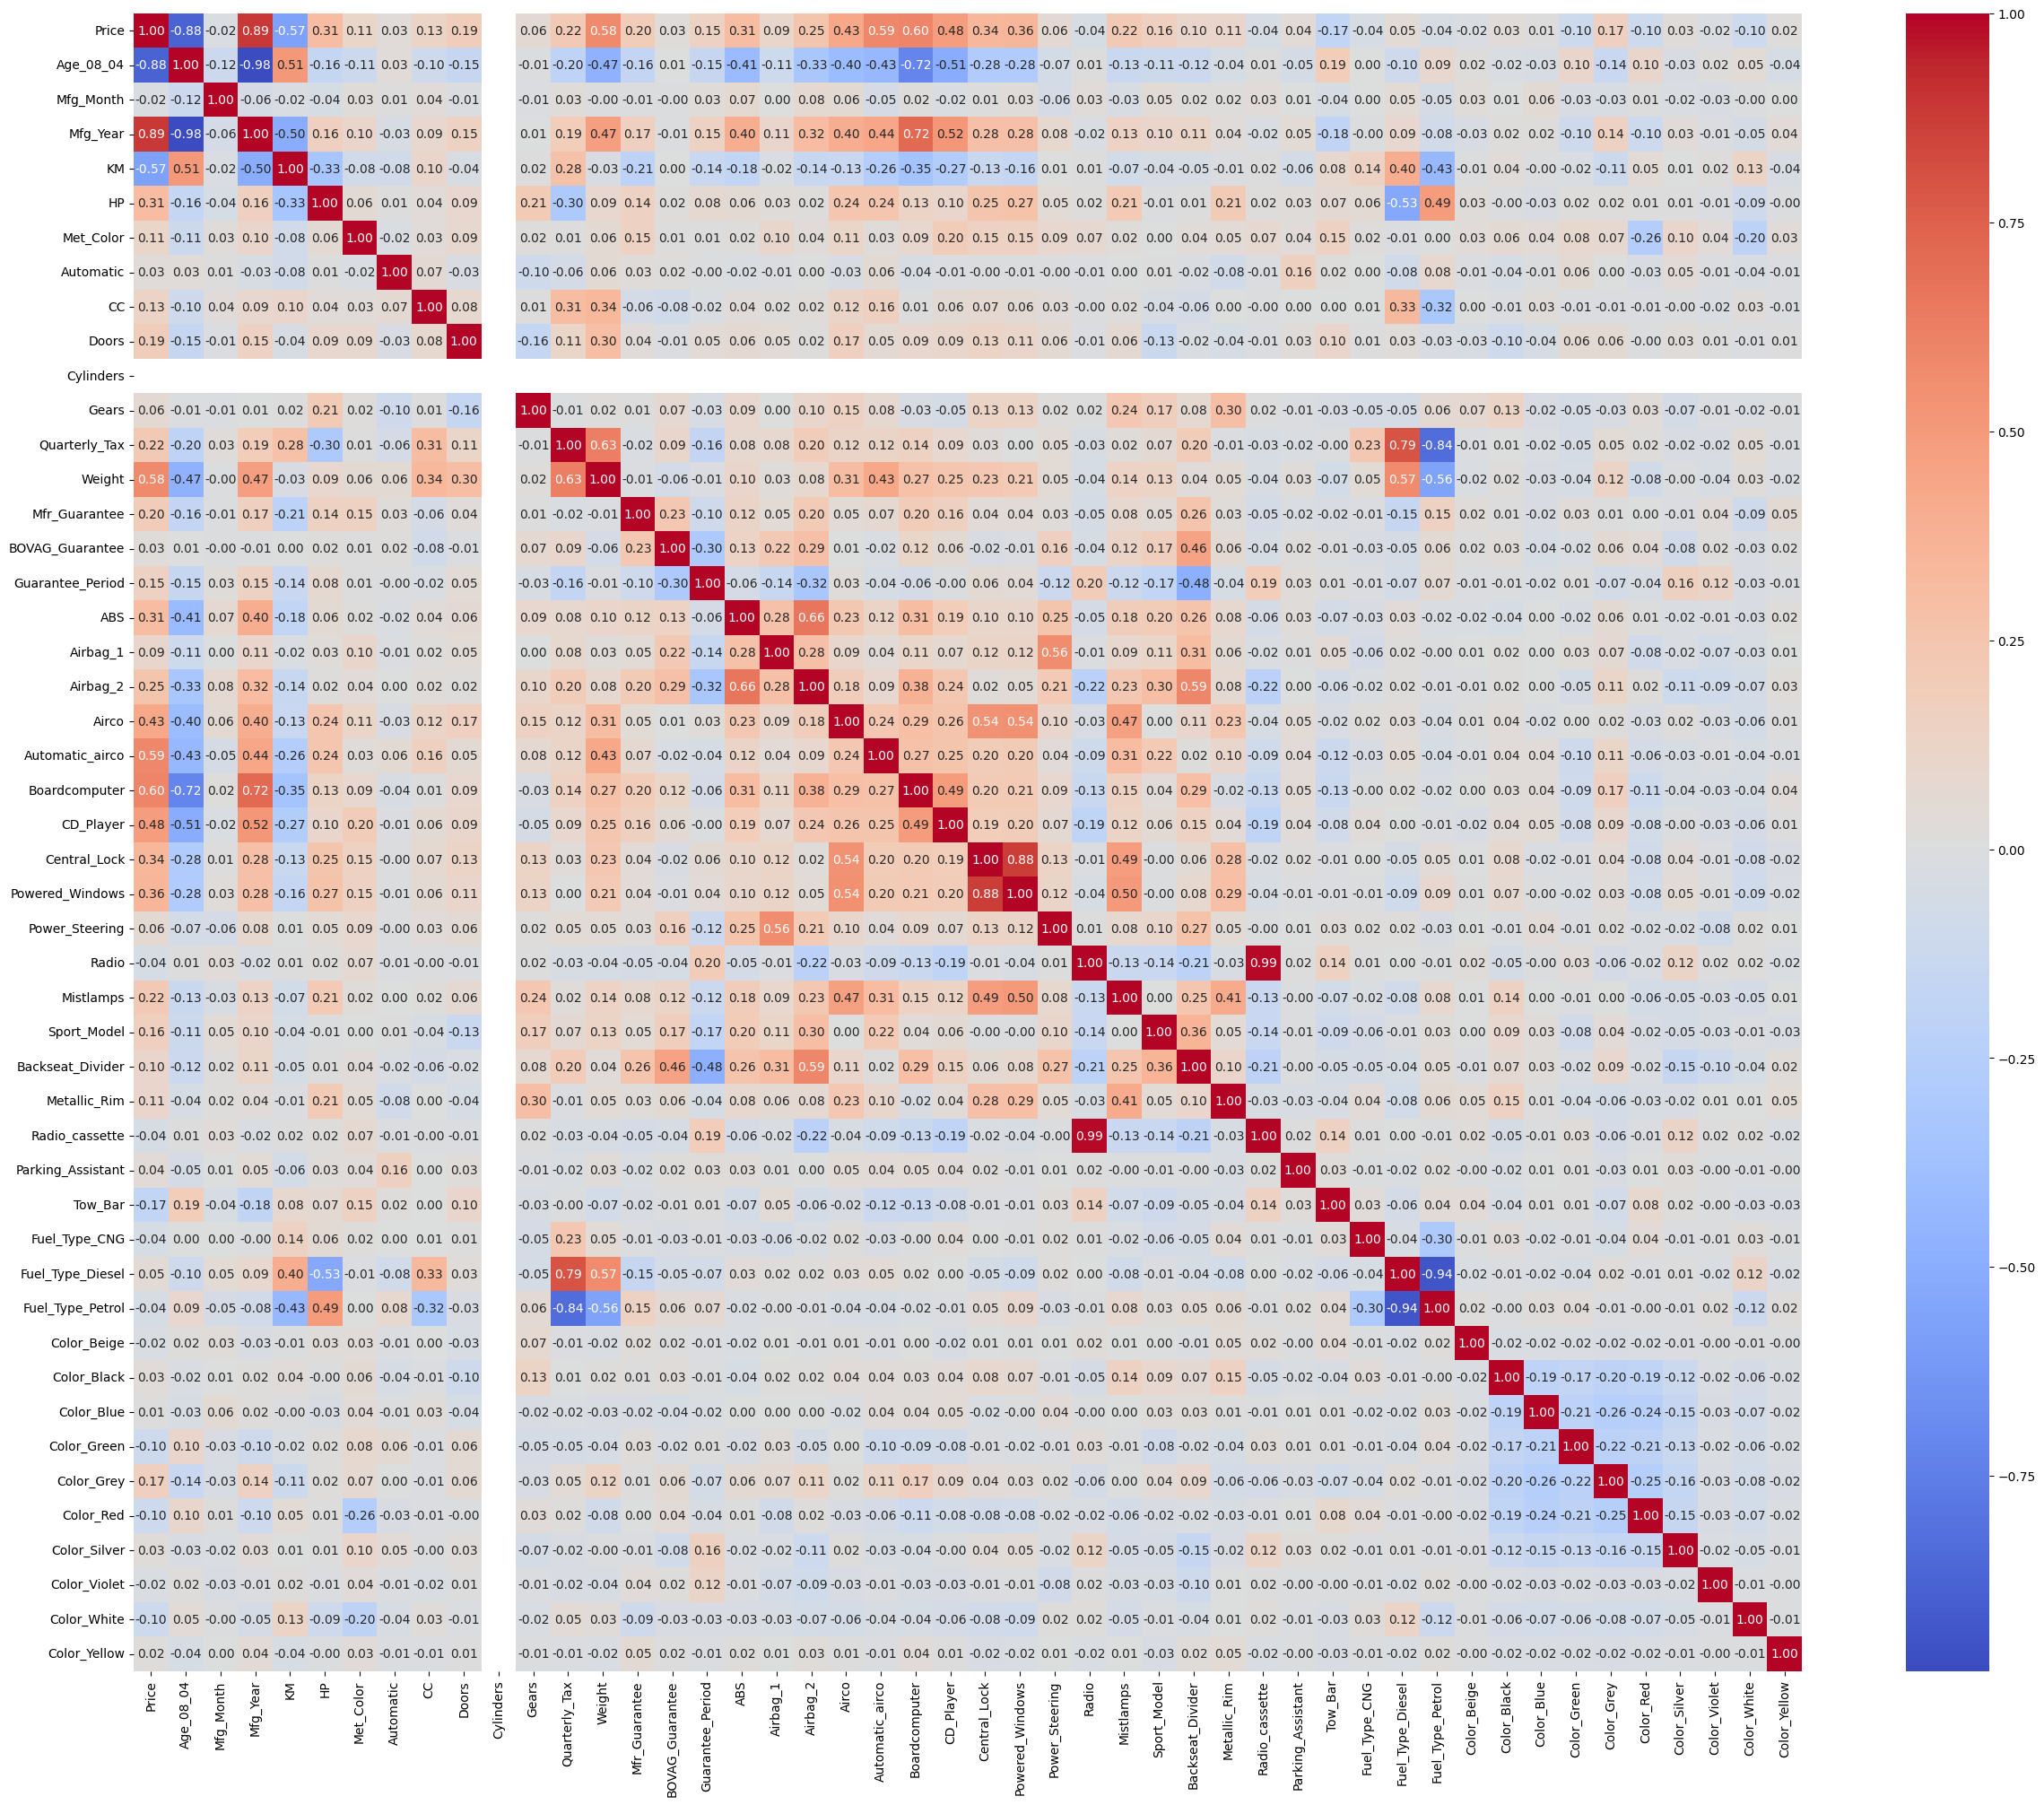

In [360]:
plt.figure(figsize=(30,24))

corr_matrix = df.drop(columns=['Id']).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

plt.figure(figsize=(30,24))

df_modified = pd.get_dummies(df, columns=['Fuel_Type', 'Color'])

corr_matrix_modified = df_modified.drop(columns=['Id']).corr(numeric_only=True)
sns.heatmap(corr_matrix_modified, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

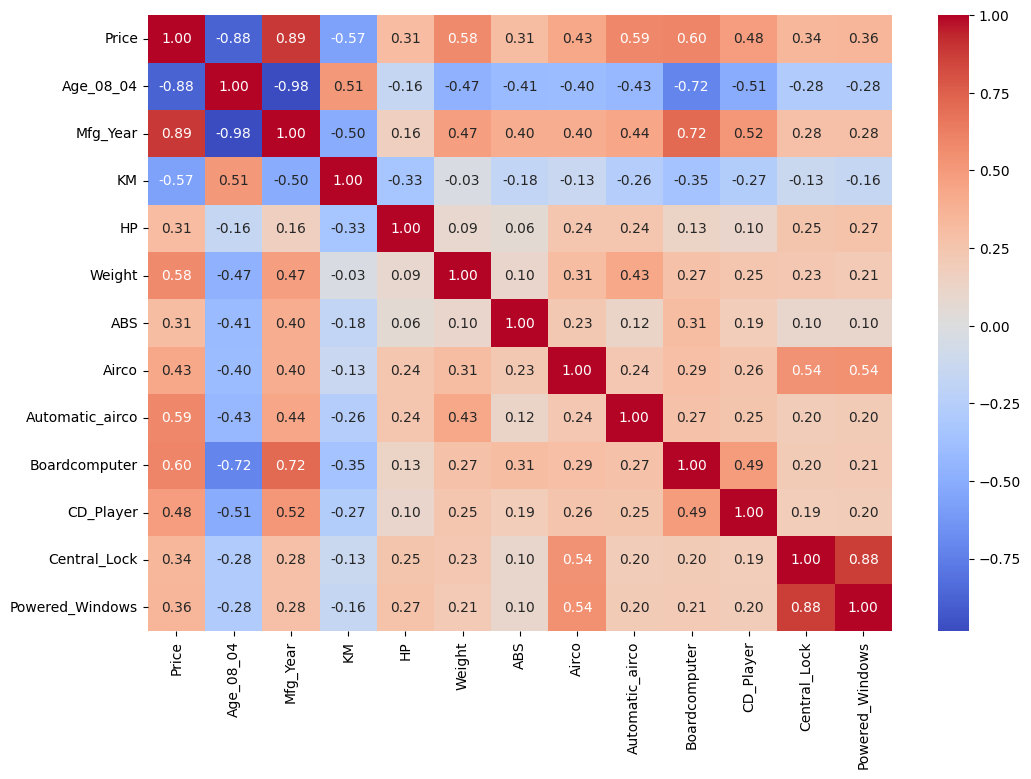

In [361]:
df_corr = pd.DataFrame(corr_matrix_modified)

X_columns = [col for col in df_corr.columns if abs(df_corr.loc['Price', col]) > 0.3] 
df_corr_X = df_corr.loc[X_columns, X_columns]

plt.figure(figsize=(12,8))

sns.heatmap(df_corr_X, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

## 4. Разделение данных

Делим данные на train и test. Обучаем на train, тестируем на test. Также добавим кросс-валидацию и выведем validation score.

In [362]:
X = df[X_columns].drop(columns=['Price'])
y = df[['Price']] #we want it to be pandas
display(X)
display(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

,Age_08_04,Mfg_Year,KM,HP,Weight,ABS,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows
0,23,2002,46986,90,1165,1,0,0,1,0,1,1
1,23,2002,72937,90,1165,1,1,0,1,1,1,0
2,24,2002,41711,90,1165,1,0,0,1,0,0,0
3,26,2002,48000,90,1165,1,0,0,1,0,0,0
4,30,2002,38500,90,1170,1,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,69,1998,20544,86,1025,1,1,0,0,0,1,1
1432,72,1998,19000,86,1015,1,0,0,0,0,0,0
1433,71,1998,17016,86,1015,0,0,0,0,0,0,0
1434,70,1998,16916,86,1015,0,0,0,0,0,0,0


,Price
0,13500
1,13750
2,13950
3,14950
4,13750
...,...
1431,7500
1432,10845
1433,8500
1434,7250


## 5. Обучение модели

In [373]:
class LR(BaseEstimator, RegressorMixin):
    def __init__(self, alpha = 1e-2, l1 = 0, l2 = 0, steps = 100000):
        self.alpha = alpha
        self.l1 = l1
        self.l2 = l2
        self.steps = steps
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
    def grad(self):
        return (2 / self.n) * (self.X.T @ (self.X @ self.w - self.y))
    def fit(self, X, y):
        X_scaled = self.scaler_x.fit_transform(X)
        self.X = np.insert(X_scaled, 0, 1, axis=1)
        self.y = self.scaler_y.fit_transform(y).flatten()
        self.w = np.zeros(self.X.shape[1])
        self.n = len(y)
        #print(self.X.shape)
        #display(self.X)
        #display(self.y)
        #display(self.w)
        #while self.metrics['MAE'](self.X, self.w, self.y) > 10000
        for i in range(self.steps + 1):
            self.w -= self.alpha * (self.grad() + self.l1 * np.sign(self.w) + self.l2 * self.w)
            #if(i % 100 == 0):
                #print(f"{i} = {self.grad()}")
    def predict(self, X):
        X_scaled = self.scaler_x.transform(X)
        X_test = np.insert(X_scaled, 0, 1, axis=1)
        return self.scaler_y.inverse_transform((X_test @ self.w).reshape(-1, 1))
    def score(self, X, y):
        y_pred = self.predict(X)
        y_test = y.to_numpy() 
        MAE = np.mean(abs(y_pred - y_test))
        MSPE = np.mean(((y_pred - y_test) / y_test) ** 2)
        R2 = 1 - (np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))
        return MAE, MSPE, R2
    def get_weights(self):
        return self.w

## 6. Построение графиков
Сейчас посмотрим на график без регуляризации. Построим два графика цен - реальной и предсказанной. Сравним их.

,idx,y_pred,y_real
594,0,10767.885320,10800
754,1,9370.561576,9950
630,2,9003.986533,7500
1259,3,8560.943367,9250
903,4,9814.995524,9750
...,...,...,...
670,354,8117.637234,5950
126,355,16616.951203,15950
1353,356,11508.544162,8250
292,357,12960.859526,10500


'MAE = 886.3789744654867'

'MSPE = 0.020352798210371094'

'R2 = 0.8881167270858358'

'CV = 0.8883250672729959'

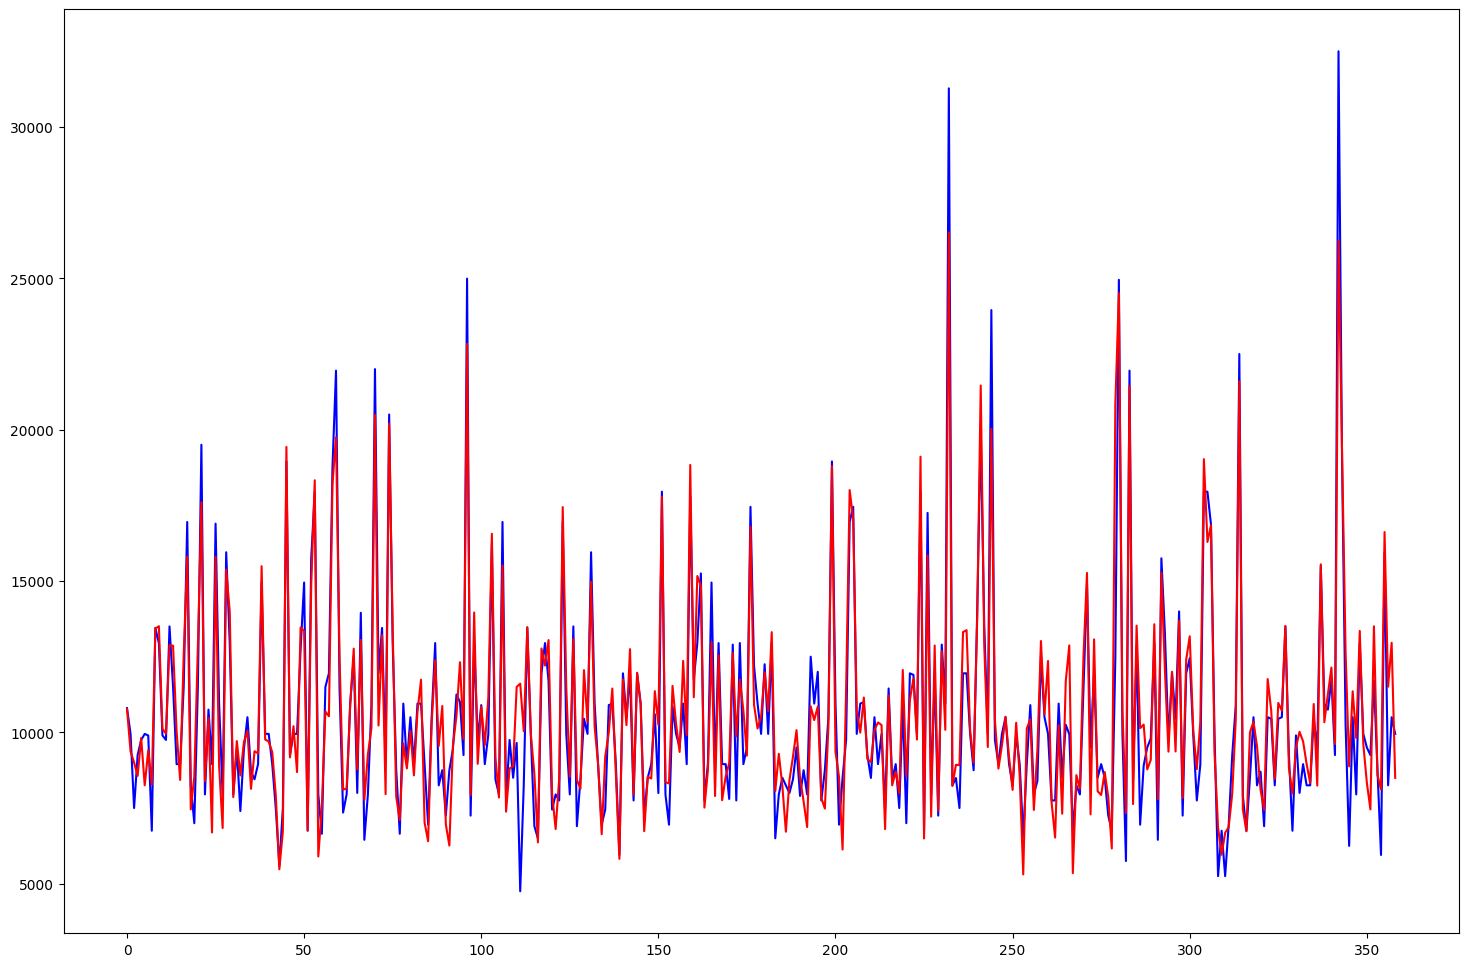

In [374]:
model = LR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test).flatten()
idx = [i for i in range(len(y_test))]
#display(y_test)
#display(y_pred)
#display(idx)
df_test = pd.DataFrame({'idx': idx, 'y_pred': y_pred, 'y_real': y_test['Price']})
display(df_test)
MAE, MSPE, R2 = model.score(X_test, y_test)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
CV = scores.mean()
display(f"MAE = {MAE}")
display(f"MSPE = {MSPE}")
display(f"R2 = {R2}")
display(f"CV = {CV}")

plt.figure(figsize=(18,12))
plt.plot(df_test['idx'], df_test['y_real'], color='blue')
plt.plot(df_test['idx'], df_test['y_pred'], color='red')
plt.show()


А сейчас попробуем перебрать гиперпараметры alpha, l1, l2, steps. Сформируем таблицу и выберем с лучшими показателями по каждой метрике.

In [375]:
alphas = [10 ** i for i in range(-6, 0)]
l1s = [10 ** i for i in range(-6, 1)]
l2s = [10 ** i for i in range(-6, 1)]
stepss = [10 ** i for i in range(3, 6)]

df_hyperparametrs = pd.DataFrame(columns=['MAE', 'MSPE', 'R2', 'alpha', 'l1', 'l2', 'steps'])

for alpha in alphas:
    for l1 in l1s:
        for l2 in l2s:
            for steps in stepss:
                model = LR(alpha, l1, l2, steps)
                model.fit(X_train, y_train)
                MAE, MSPE, R2 = model.score(X_test, y_test)
                df_hyperparametrs.loc[len(df_hyperparametrs)] = [MAE, MSPE, R2, alpha, l1, l2, steps]
display(df_hyperparametrs)

,MAE,MSPE,R2,alpha,l1,l2,steps
0,6251.012511,0.315370,-2.749425,0.000001,0.000001,0.000001,1000.0
1,5840.339953,0.274197,-2.364139,0.000001,0.000001,0.000001,10000.0
2,3077.933460,0.084082,-0.371185,0.000001,0.000001,0.000001,100000.0
3,6251.012511,0.315370,-2.749425,0.000001,0.000001,0.000010,1000.0
4,5840.339973,0.274197,-2.364139,0.000001,0.000001,0.000010,10000.0
...,...,...,...,...,...,...,...
877,2747.046019,0.077462,-0.062537,0.100000,1.000000,0.100000,10000.0
878,2789.363979,0.093071,0.034841,0.100000,1.000000,0.100000,100000.0
879,12494.041115,1.953216,-11.549515,0.100000,1.000000,1.000000,1000.0
880,12494.041115,1.953216,-11.549515,0.100000,1.000000,1.000000,10000.0


Проанализируем данные и дропнем ненужные.
> После анализа немного подкорректировал range списков выше

In [376]:
df_hyperparametrs_copy = df_hyperparametrs[df_hyperparametrs['R2'] > 0.85]
display(df_hyperparametrs_copy.head())
df_sorted_MAE = df_hyperparametrs_copy.sort_values(by='MAE')
df_sorted_MSPE = df_hyperparametrs_copy.sort_values(by='MSPE')
df_sorted_R2 = df_hyperparametrs_copy.sort_values(by='R2', ascending=False)
display(df_sorted_MAE.head(10))
display(df_sorted_MSPE.head(10))
display(df_sorted_R2.head(10))

,MAE,MSPE,R2,alpha,l1,l2,steps
443,893.687554,0.020174,0.886730,0.001,0.000001,0.000001,100000.0
446,893.667969,0.020173,0.886729,0.001,0.000001,0.000010,100000.0
449,893.472345,0.020161,0.886728,0.001,0.000001,0.000100,100000.0
452,891.701012,0.020055,0.886638,0.001,0.000001,0.001000,100000.0
455,894.747754,0.019743,0.880560,0.001,0.000001,0.010000,100000.0


,MAE,MSPE,R2,alpha,l1,l2,steps
641,883.549819,0.020097,0.888251,0.01,0.000100,0.0010,100000.0
787,883.549911,0.020097,0.888251,0.10,0.000100,0.0010,10000.0
788,883.748148,0.020106,0.888224,0.10,0.000100,0.0010,100000.0
620,883.802400,0.020146,0.888268,0.01,0.000010,0.0010,100000.0
766,883.802411,0.020146,0.888268,0.10,0.000010,0.0010,10000.0
767,883.828909,0.020148,0.888264,0.10,0.000010,0.0010,100000.0
599,883.946791,0.020152,0.888263,0.01,0.000001,0.0010,100000.0
745,883.946797,0.020152,0.888263,0.10,0.000001,0.0010,10000.0
746,883.960615,0.020153,0.888260,0.10,0.000001,0.0010,100000.0
638,885.100782,0.020281,0.888200,0.01,0.000100,0.0001,100000.0


,MAE,MSPE,R2,alpha,l1,l2,steps
623,891.712168,0.019695,0.881553,0.01,0.000010,0.01,100000.0
769,891.712168,0.019695,0.881553,0.10,0.000010,0.01,10000.0
770,891.712169,0.019695,0.881553,0.10,0.000010,0.01,100000.0
602,891.685520,0.019695,0.881610,0.01,0.000001,0.01,100000.0
748,891.685520,0.019695,0.881610,0.10,0.000001,0.01,10000.0
749,891.685520,0.019695,0.881610,0.10,0.000001,0.01,100000.0
644,892.472019,0.019711,0.880922,0.01,0.000100,0.01,100000.0
791,892.481200,0.019712,0.880921,0.10,0.000100,0.01,100000.0
790,892.482510,0.019712,0.880920,0.10,0.000100,0.01,10000.0
747,894.733894,0.019743,0.880566,0.10,0.000001,0.01,1000.0


,MAE,MSPE,R2,alpha,l1,l2,steps
620,883.802400,0.020146,0.888268,0.01,0.000010,0.0010,100000.0
766,883.802411,0.020146,0.888268,0.10,0.000010,0.0010,10000.0
767,883.828909,0.020148,0.888264,0.10,0.000010,0.0010,100000.0
599,883.946791,0.020152,0.888263,0.01,0.000001,0.0010,100000.0
745,883.946797,0.020152,0.888263,0.10,0.000001,0.0010,10000.0
746,883.960615,0.020153,0.888260,0.10,0.000001,0.0010,100000.0
641,883.549819,0.020097,0.888251,0.01,0.000100,0.0010,100000.0
787,883.549911,0.020097,0.888251,0.10,0.000100,0.0010,10000.0
788,883.748148,0.020106,0.888224,0.10,0.000100,0.0010,100000.0
638,885.100782,0.020281,0.888200,0.01,0.000100,0.0001,100000.0


Теперь посчитаем рейтинг р2 кросс-валидации. Считать будем по датафрейму с отсортированным р2, т.к. там наиболее оптимальные параметры. 

In [377]:
CV_col = []

for i in range(len(df_sorted_R2)):
    alpha = df_sorted_R2.iloc[i, 3]
    l1 = df_sorted_R2.iloc[i, 4]
    l2 = df_sorted_R2.iloc[i, 5]
    steps = df_sorted_R2.iloc[i, 6]
    
    model = LR(alpha, l1, l2, int(steps))
    model.fit(X_train, y_train)
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    CV = scores.mean()
    
    CV_col.append(CV)
    
df_sorted_R2['CV'] = CV_col
display(df_sorted_R2.head(10))

df_sorted_CV = df_sorted_R2.sort_values(by='CV', ascending=False)
display(df_sorted_CV.head(10))

,MAE,MSPE,R2,alpha,l1,l2,steps,CV
620,883.802400,0.020146,0.888268,0.01,0.000010,0.0010,100000.0,0.888398
766,883.802411,0.020146,0.888268,0.10,0.000010,0.0010,10000.0,0.888398
767,883.828909,0.020148,0.888264,0.10,0.000010,0.0010,100000.0,0.888381
599,883.946791,0.020152,0.888263,0.01,0.000001,0.0010,100000.0,0.888418
745,883.946797,0.020152,0.888263,0.10,0.000001,0.0010,10000.0,0.888418
746,883.960615,0.020153,0.888260,0.10,0.000001,0.0010,100000.0,0.888403
641,883.549819,0.020097,0.888251,0.01,0.000100,0.0010,100000.0,0.888131
787,883.549911,0.020097,0.888251,0.10,0.000100,0.0010,10000.0,0.888131
788,883.748148,0.020106,0.888224,0.10,0.000100,0.0010,100000.0,0.888101
638,885.100782,0.020281,0.888200,0.01,0.000100,0.0001,100000.0,0.888117


,MAE,MSPE,R2,alpha,l1,l2,steps,CV
599,883.946791,0.020152,0.888263,0.01,0.000001,0.0010,100000.0,0.888418
745,883.946797,0.020152,0.888263,0.10,0.000001,0.0010,10000.0,0.888418
746,883.960615,0.020153,0.888260,0.10,0.000001,0.0010,100000.0,0.888403
620,883.802400,0.020146,0.888268,0.01,0.000010,0.0010,100000.0,0.888398
766,883.802411,0.020146,0.888268,0.10,0.000010,0.0010,10000.0,0.888398
767,883.828909,0.020148,0.888264,0.10,0.000010,0.0010,100000.0,0.888381
596,886.057937,0.020330,0.888149,0.01,0.000001,0.0001,100000.0,0.888348
742,886.057950,0.020330,0.888149,0.10,0.000001,0.0001,10000.0,0.888348
617,885.907566,0.020324,0.888161,0.01,0.000010,0.0001,100000.0,0.888335
763,885.907592,0.020324,0.888161,0.10,0.000010,0.0001,10000.0,0.888335


## 7. Вывод. 
Впринципе l1, l2 регуляция тут впринципе не нужна, но пусть будет, количество признаков я менял, делал их меньше, результат хуже, не прям сильно, при 6 признаках CV score падал на 0.1, но при 13 признаках модель более стабильная что ли.  
Построим теперь графики с оптимальными значениями гиперпараметров.

,idx,y_pred,y_real
594,0,10767.885320,10800
754,1,9370.561576,9950
630,2,9003.986533,7500
1259,3,8560.943367,9250
903,4,9814.995524,9750
...,...,...,...
670,354,8117.637234,5950
126,355,16616.951203,15950
1353,356,11508.544162,8250
292,357,12960.859526,10500


'MAE = 886.3789744654867'

'MSPE = 0.020352798210371094'

'R2 = 0.8881167270858358'

'CV = 0.8883250672729959'

weights = [ 0.19036096 -0.06522953  0.27787287 -0.15847443  0.09309129  0.24305887
 -0.01211731  0.00792749  0.08563083 -0.01669326  0.01080091 -0.00510515
  0.01782852]


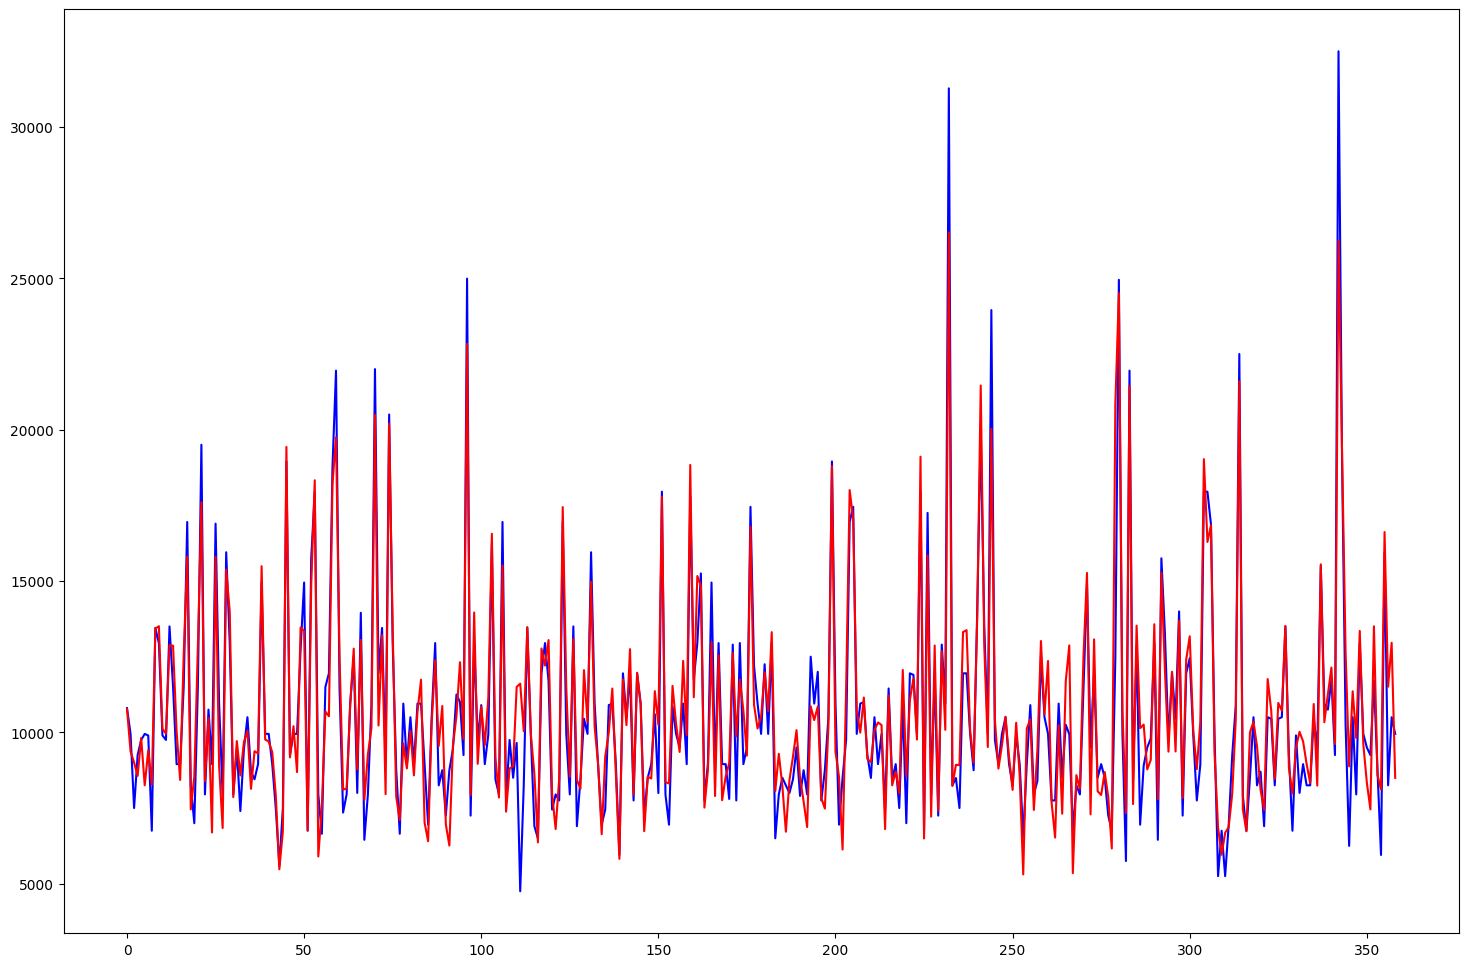

,idx,y_pred,y_real
594,0,10788.239230,10800
754,1,9378.541809,9950
630,2,8954.354868,7500
1259,3,8574.333910,9250
903,4,9806.972497,9750
...,...,...,...
670,354,8177.253950,5950
126,355,16564.870197,15950
1353,356,11531.729117,8250
292,357,12953.638508,10500


'MAE = 883.9467910975756'

'MSPE = 0.02015211296833934'

'R2 = 0.8882630347392151'

'CV = 0.8884183276947812'

weights = [ 0.18956516 -0.06571889  0.27600039 -0.15197866  0.09267523  0.22933394
 -0.01125368  0.00838423  0.0877272  -0.01531828  0.01143894 -0.00451619
  0.01775971]


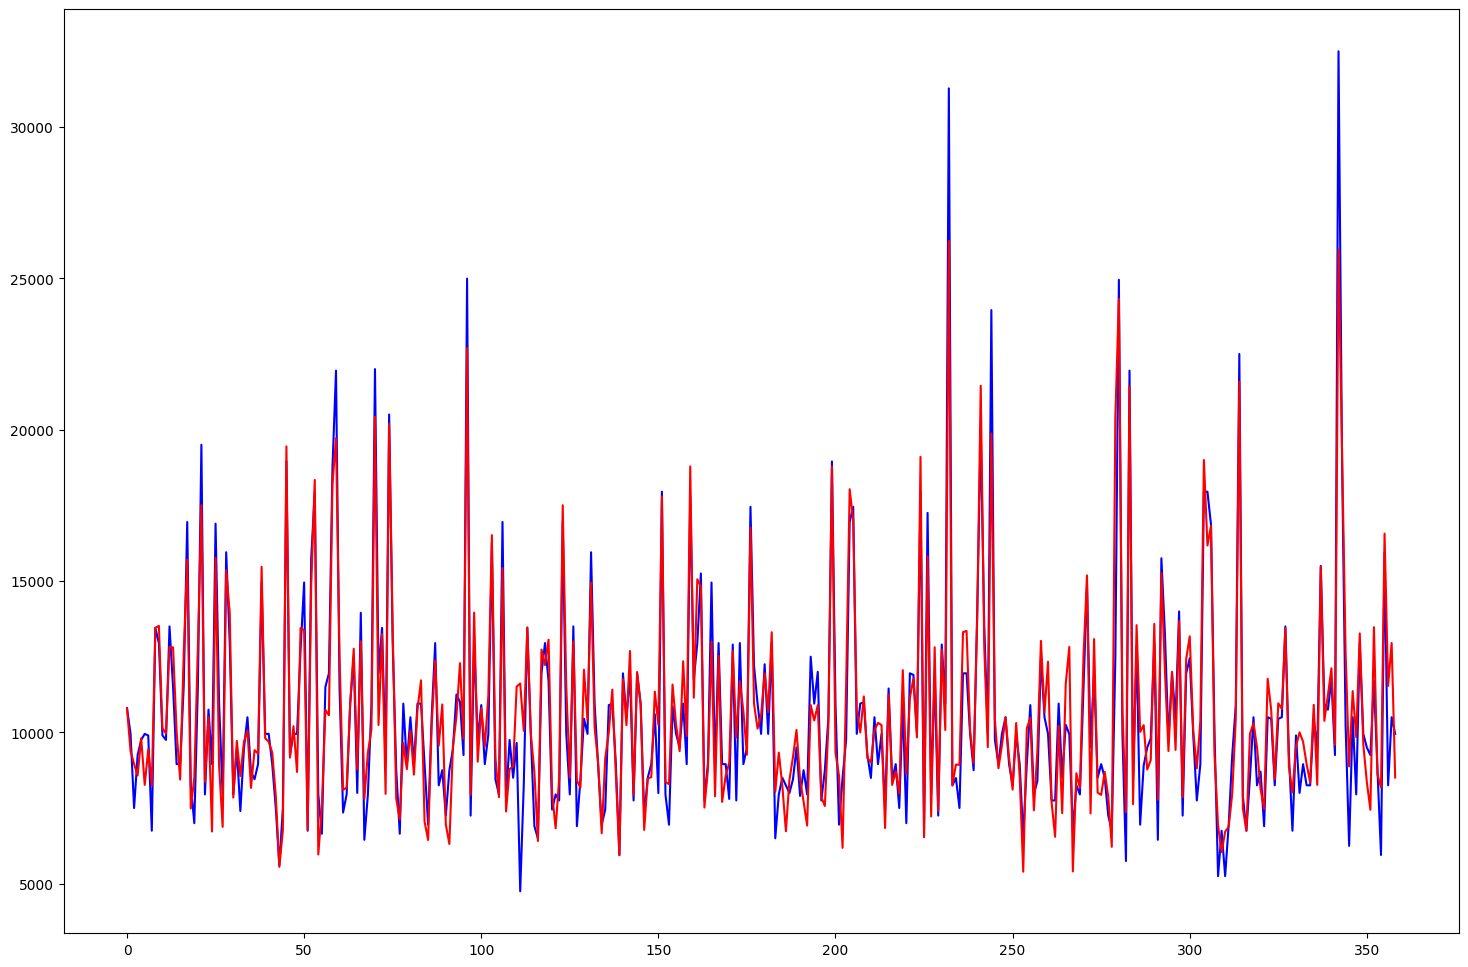

In [378]:
model = LR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test).flatten()
idx = [i for i in range(len(y_test))]
#display(y_test)
#display(y_pred)
#display(idx)
df_test = pd.DataFrame({'idx': idx, 'y_pred': y_pred, 'y_real': y_test['Price']})
display(df_test)
MAE, MSPE, R2 = model.score(X_test, y_test)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
CV = scores.mean()
display(f"MAE = {MAE}")
display(f"MSPE = {MSPE}")
display(f"R2 = {R2}")
display(f"CV = {CV}")
print(f"weights = {model.get_weights()}")

plt.figure(figsize=(18,12))
plt.plot(df_test['idx'], df_test['y_real'], color='blue')
plt.plot(df_test['idx'], df_test['y_pred'], color='red')
plt.show()

model = LR(1e-2, 0.000001, 0.001, 100000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test).flatten()
idx = [i for i in range(len(y_test))]
#display(y_test)
#display(y_pred)
#display(idx)
df_test = pd.DataFrame({'idx': idx, 'y_pred': y_pred, 'y_real': y_test['Price']})
display(df_test)
MAE, MSPE, R2 = model.score(X_test, y_test)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
CV = scores.mean()
display(f"MAE = {MAE}")
display(f"MSPE = {MSPE}")
display(f"R2 = {R2}")
display(f"CV = {CV}")
print(f"weights = {model.get_weights()}")

plt.figure(figsize=(18,12))
plt.plot(df_test['idx'], df_test['y_real'], color='blue')
plt.plot(df_test['idx'], df_test['y_pred'], color='red')
plt.show()


По графику видно, что диссперсия равномерная, ошибки в среднем нулевые, корреляций между ошибками нет. Веса примерно одинаковые, модель не пытается подстроится под шумы. Кросс-валидация показывает результат 0.89, как и метрика R2, а значит модель не переобучилась. Модель с регуляризацией получилась немного лучше. Результаты хорошие, 90% точности для прогнозирования цен на машины с помощью линейной регрессии это хорошо.